# Comprehensive Evaluation of Calibration Methods

This notebook provides a systematic evaluation of all calibration methods in the `rank_preserving_calibration` package. We evaluate methods across multiple dimensions:

1. **Constraint Satisfaction**: How well do solutions satisfy row simplex, column marginals, and rank constraints?
2. **Informativeness**: How much discriminative power is preserved (vs. "flat" solutions)?
3. **Fidelity**: How close is the calibrated solution to the original probabilities?
4. **Computation**: Iterations and timing.

## Methods Evaluated

| Method | Description | Key Trade-off |
|--------|-------------|---------------|
| `calibrate_dykstra` | Exact projection via Dykstra's algorithm | Exact constraints, may flatten |
| `calibrate_admm` | ADMM with final snap | Similar to Dykstra, different path |
| `calibrate_soft` | Gradient descent with soft penalties | Tunable trade-offs |
| `calibrate_soft_admm` | ADMM soft calibration | Better convergence for soft |
| `calibrate_ipf` | Pure IPF (raking) | Preserves ratios, no rank constraint |
| `calibrate_two_stage` | IPF + isotonic projection | Less flat, approximate constraints |

In [1]:
import sys
import time
import warnings
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Add parent directory for development
sys.path.insert(0, "..")

from rank_preserving_calibration import (
    calibrate_admm,
    calibrate_dykstra,
    calibrate_ipf,
    calibrate_soft,
    calibrate_soft_admm,
    calibrate_two_stage,
    flatness_bound,
    flatness_metrics,
    informativeness_ratio,
    isotonic_metrics,
    marginal_shift_metrics,
)

# Import test data helpers
sys.path.insert(0, "../tests")
from data_helpers import (
    create_realistic_classifier_case,
    create_survey_reweighting_case,
)

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
np.random.seed(42)

print("Setup complete. All methods and utilities loaded.")

Setup complete. All methods and utilities loaded.


## 1. Unified Method Interface

We define a unified wrapper for all calibration methods to simplify comparison.

In [2]:
from rank_preserving_calibration.calibration import CalibrationError


@dataclass
class MethodResult:
    """Unified result container for all methods."""

    name: str
    Q: np.ndarray
    converged: bool
    iterations: int
    elapsed_time: float
    max_row_error: float
    max_col_error: float
    max_rank_violation: float
    extra: dict = None
    failed: bool = False
    error_msg: str = ""


def run_method(name: str, P: np.ndarray, M: np.ndarray, **kwargs) -> MethodResult:
    """Run a calibration method and return unified result.

    Uses relaxed tolerances for difficult cases and catches convergence failures.
    """
    start_time = time.time()

    try:
        if name == "dykstra":
            # Use relaxed tolerance for difficult cases
            kwargs.setdefault("tol", 1e-5)
            kwargs.setdefault("max_iters", 5000)
            result = calibrate_dykstra(P, M, **kwargs)
            Q = result.Q
            converged = result.converged
            iterations = result.iterations
            max_row_error = result.max_row_error
            max_col_error = result.max_col_error
            max_rank_violation = result.max_rank_violation
            extra = {}

        elif name == "admm":
            # Use relaxed tolerance
            kwargs.setdefault("tol", 1e-4)
            kwargs.setdefault("max_iters", 2000)
            result = calibrate_admm(P, M, **kwargs)
            Q = result.Q
            converged = result.converged
            iterations = result.iterations
            max_row_error = result.max_row_error
            max_col_error = result.max_col_error
            max_rank_violation = result.max_rank_violation
            extra = {}

        elif name == "soft":
            lam_m = kwargs.pop("lam_m", 1.0)
            lam_r = kwargs.pop("lam_r", 10.0)
            result = calibrate_soft(P, M, lam_m=lam_m, lam_r=lam_r, **kwargs)
            Q = result.Q
            converged = result.converged
            iterations = result.iterations
            max_row_error = result.max_row_error
            max_col_error = result.max_col_error
            max_rank_violation = result.max_rank_violation
            extra = {
                "lam_m": lam_m,
                "lam_r": lam_r,
                "fit_term": result.fit_term,
                "marginal_term": result.marginal_term,
                "rank_term": result.rank_term,
            }

        elif name == "soft_admm":
            lam_m = kwargs.pop("lam_m", 1.0)
            lam_r = kwargs.pop("lam_r", 10.0)
            rho = kwargs.pop("rho", 1.0)
            result = calibrate_soft_admm(
                P, M, lam_m=lam_m, lam_r=lam_r, rho=rho, **kwargs
            )
            Q = result.Q
            converged = result.converged
            iterations = result.iterations
            max_row_error = result.max_row_error
            max_col_error = result.max_col_error
            max_rank_violation = result.max_rank_violation
            extra = {
                "lam_m": lam_m,
                "lam_r": lam_r,
                "rho": rho,
                "fit_term": result.fit_term,
                "marginal_term": result.marginal_term,
                "rank_term": result.rank_term,
            }

        elif name == "ipf":
            result = calibrate_ipf(P, M, **kwargs)
            Q = result.Q
            converged = result.converged
            iterations = result.iterations
            max_row_error = result.max_row_error
            max_col_error = result.max_col_error
            # IPF doesn't enforce rank constraints, compute violation
            iso = isotonic_metrics(Q, P)
            max_rank_violation = iso["max_rank_violation"]
            extra = {}

        elif name == "two_stage":
            result = calibrate_two_stage(P, M, **kwargs)
            Q = result.Q
            converged = result.converged
            iterations = result.ipf_iterations + result.projection_iterations
            max_row_error = result.max_row_error
            max_col_error = result.max_col_error
            max_rank_violation = result.max_rank_violation
            extra = {
                "ipf_iterations": result.ipf_iterations,
                "projection_iterations": result.projection_iterations,
            }

        else:
            raise ValueError(f"Unknown method: {name}")

        elapsed_time = time.time() - start_time

        return MethodResult(
            name=name,
            Q=Q,
            converged=converged,
            iterations=iterations,
            elapsed_time=elapsed_time,
            max_row_error=max_row_error,
            max_col_error=max_col_error,
            max_rank_violation=max_rank_violation,
            extra=extra or {},
            failed=False,
            error_msg="",
        )

    except CalibrationError as e:
        # Method failed to converge - return a placeholder result
        elapsed_time = time.time() - start_time
        N, J = P.shape
        return MethodResult(
            name=name,
            Q=np.full((N, J), 1.0 / J),  # Uniform placeholder
            converged=False,
            iterations=-1,
            elapsed_time=elapsed_time,
            max_row_error=np.nan,
            max_col_error=np.nan,
            max_rank_violation=np.nan,
            extra={},
            failed=True,
            error_msg=str(e)[:100],
        )


def collect_metrics(P: np.ndarray, M: np.ndarray, result: MethodResult) -> dict:
    """Collect comprehensive metrics for a calibration result."""
    Q = result.Q

    # Handle failed methods
    if result.failed:
        return {
            "name": result.name,
            "converged": False,
            "iterations": -1,
            "elapsed_time": result.elapsed_time,
            "max_row_error": np.nan,
            "max_col_error": np.nan,
            "max_rank_violation": np.nan,
            "variance_ratio": np.nan,
            "mean_column_variance": np.nan,
            "distance_to_uniform": np.nan,
            "frobenius_dist": np.nan,
            "pred_change_rate": np.nan,
            "total_ratio": np.nan,
            "mean_column_ratio": np.nan,
            "failed": True,
            **result.extra,
        }

    # Flatness metrics
    flat = flatness_metrics(Q, P, M)

    # Informativeness
    info = informativeness_ratio(Q, P)

    # Distance from P
    frobenius_dist = float(np.linalg.norm(Q - P))

    # Prediction changes
    orig_pred = np.argmax(P, axis=1)
    cal_pred = np.argmax(Q, axis=1)
    pred_change_rate = float(np.mean(orig_pred != cal_pred))

    return {
        "name": result.name,
        "converged": result.converged,
        "iterations": result.iterations,
        "elapsed_time": result.elapsed_time,
        "max_row_error": result.max_row_error,
        "max_col_error": result.max_col_error,
        "max_rank_violation": result.max_rank_violation,
        "variance_ratio": flat.get("variance_ratio", np.nan),
        "mean_column_variance": flat["mean_column_variance"],
        "distance_to_uniform": flat.get("distance_to_uniform", np.nan),
        "frobenius_dist": frobenius_dist,
        "pred_change_rate": pred_change_rate,
        "total_ratio": info["total_ratio"],
        "mean_column_ratio": info["mean_column_ratio"],
        "failed": False,
        **result.extra,
    }


print("Method wrappers defined.")

Method wrappers defined.


## 2. Data Generation Functions

We generate test data at various shift magnitudes to study method behavior.

In [3]:
def generate_shifted_data(
    N: int = 100,
    J: int = 4,
    shift_pct: float = 0.0,
    seed: int = 42,
) -> tuple[np.ndarray, np.ndarray, dict]:
    """Generate probability matrix P and target marginals M with controlled shift.

    Args:
        N: Number of samples
        J: Number of classes
        shift_pct: Percentage shift from empirical marginals (0-100)
        seed: Random seed

    Returns:
        P: Probability matrix (N, J)
        M: Target marginals (J,)
        info: Dictionary with shift metrics
    """
    rng = np.random.default_rng(seed)

    # Generate base probabilities
    P = rng.dirichlet(np.ones(J), size=N)

    # Empirical marginals
    empirical = P.sum(axis=0)

    # Create shifted target
    if shift_pct == 0:
        M = empirical.copy()
    else:
        # Create a shift direction
        shift_direction = rng.standard_normal(J)
        shift_direction = shift_direction - shift_direction.mean()  # Zero-sum
        shift_direction = shift_direction / np.linalg.norm(shift_direction)

        # Scale shift by percentage of total mass
        shift_magnitude = (shift_pct / 100.0) * N
        M = empirical + shift_magnitude * shift_direction

        # Ensure positive and sum to N
        M = np.maximum(M, 0.1)
        M = M * (N / M.sum())

    # Compute shift metrics
    shift = marginal_shift_metrics(P, M)
    bound = flatness_bound(P, M)

    info = {
        "N": N,
        "J": J,
        "shift_pct": shift_pct,
        "l2_shift": shift["l2_shift"],
        "relative_l2_shift": shift["relative_l2_shift"],
        "flatness_risk": bound["flatness_risk"],
        "expected_variance_ratio": bound["expected_variance_ratio"],
    }

    return P, M, info


# Test data generation
P_test, M_test, info_test = generate_shifted_data(N=100, J=4, shift_pct=25)
print(f"Test data: N={info_test['N']}, J={info_test['J']}")
print(f"Shift: {info_test['shift_pct']}%, L2={info_test['l2_shift']:.3f}")
print(f"Flatness risk: {info_test['flatness_risk']:.3f}")

Test data: N=100, J=4
Shift: 25%, L2=25.000
Flatness risk: 0.250


## 3. Experiment 1: Shift Magnitude Study

How does each method behave as the distribution shift increases?

In [4]:
def run_shift_experiment(
    shift_levels: list[float] = [0, 10, 25, 50],
    N: int = 50,
    J: int = 3,
    seed: int = 42,
) -> pd.DataFrame:
    """Run all methods at various shift levels."""

    methods = [
        ("dykstra", {}),
        ("admm", {}),
        ("soft", {"lam_m": 1.0, "lam_r": 10.0}),
        ("ipf", {}),
        ("two_stage", {}),
    ]

    results = []

    for shift_pct in shift_levels:
        print(f"Running shift={shift_pct}%...")
        P, M, info = generate_shifted_data(N=N, J=J, shift_pct=shift_pct, seed=seed)

        for method_name, kwargs in methods:
            result = run_method(method_name, P, M, **kwargs)
            metrics = collect_metrics(P, M, result)
            metrics["shift_pct"] = shift_pct
            metrics["l2_shift"] = info["l2_shift"]
            metrics["flatness_risk"] = info["flatness_risk"]

            # Create descriptive name for soft variants
            if method_name == "soft":
                lam_m = kwargs.get("lam_m", 1.0)
                metrics["name"] = f"soft(m={lam_m})"

            results.append(metrics)

    return pd.DataFrame(results)


# Run experiment
print("Experiment 1: Shift Magnitude Study")
print("=" * 40)
df_shift = run_shift_experiment(shift_levels=[0, 10, 25, 50], N=50, J=3)
print(f"\nCollected {len(df_shift)} results")

Experiment 1: Shift Magnitude Study
Running shift=0%...


Running shift=10%...


Running shift=25%...


Running shift=50%...



Collected 20 results


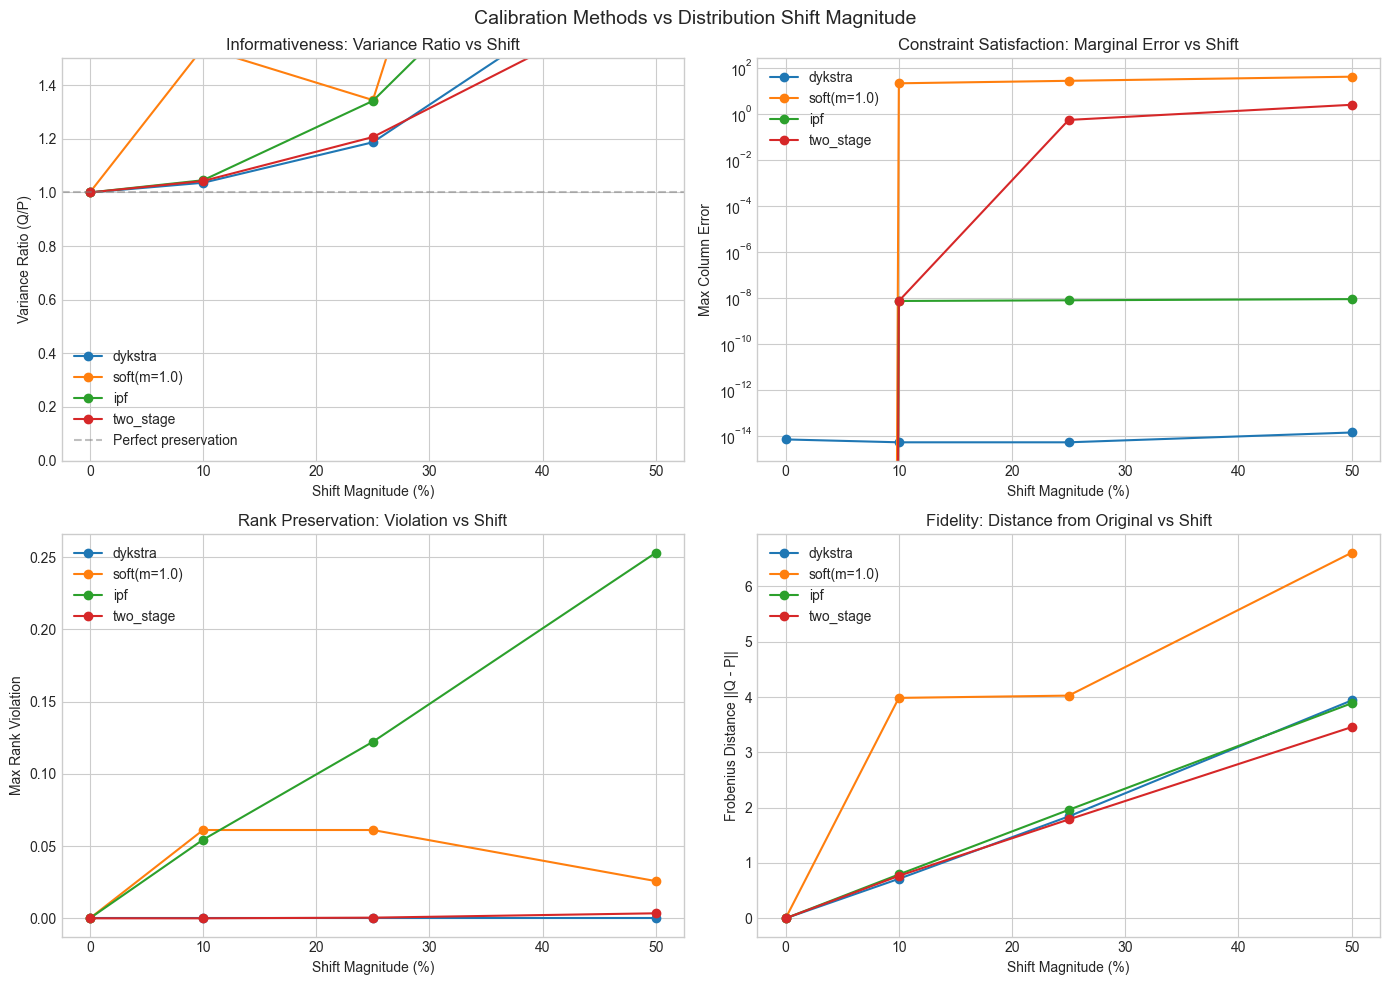

In [5]:
# Visualize shift experiment results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Calibration Methods vs Distribution Shift Magnitude", fontsize=14)

methods_to_plot = ["dykstra", "soft(m=1.0)", "ipf", "two_stage"]

# 1. Variance ratio vs shift
ax = axes[0, 0]
for method in methods_to_plot:
    data = df_shift[df_shift["name"] == method]
    if len(data) > 0:
        ax.plot(data["shift_pct"], data["variance_ratio"].fillna(0), "o-", label=method)
ax.axhline(y=1.0, color="gray", linestyle="--", alpha=0.5, label="Perfect preservation")
ax.set_xlabel("Shift Magnitude (%)")
ax.set_ylabel("Variance Ratio (Q/P)")
ax.set_title("Informativeness: Variance Ratio vs Shift")
ax.legend(loc="lower left")
ax.set_ylim(0, 1.5)

# 2. Max column error vs shift
ax = axes[0, 1]
for method in methods_to_plot:
    data = df_shift[df_shift["name"] == method]
    if len(data) > 0:
        col_err = data["max_col_error"].fillna(1e-10)
        ax.plot(data["shift_pct"], col_err, "o-", label=method)
ax.set_xlabel("Shift Magnitude (%)")
ax.set_ylabel("Max Column Error")
ax.set_title("Constraint Satisfaction: Marginal Error vs Shift")
ax.legend(loc="upper left")
ax.set_yscale("log")

# 3. Max rank violation vs shift
ax = axes[1, 0]
for method in methods_to_plot:
    data = df_shift[df_shift["name"] == method]
    if len(data) > 0:
        ax.plot(
            data["shift_pct"], data["max_rank_violation"].fillna(0), "o-", label=method
        )
ax.set_xlabel("Shift Magnitude (%)")
ax.set_ylabel("Max Rank Violation")
ax.set_title("Rank Preservation: Violation vs Shift")
ax.legend(loc="upper left")

# 4. Distance from P vs shift
ax = axes[1, 1]
for method in methods_to_plot:
    data = df_shift[df_shift["name"] == method]
    if len(data) > 0:
        ax.plot(data["shift_pct"], data["frobenius_dist"].fillna(0), "o-", label=method)
ax.set_xlabel("Shift Magnitude (%)")
ax.set_ylabel("Frobenius Distance ||Q - P||")
ax.set_title("Fidelity: Distance from Original vs Shift")
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

In [6]:
# Summary table for shift experiment
print("\nShift Experiment Summary (at 50% shift)")
print("=" * 80)

df_50 = df_shift[df_shift["shift_pct"] == 50][
    [
        "name",
        "variance_ratio",
        "max_col_error",
        "max_rank_violation",
        "frobenius_dist",
        "pred_change_rate",
        "converged",
    ]
].copy()

df_50 = df_50.sort_values("variance_ratio", ascending=False)
print(df_50.to_string(index=False))


Shift Experiment Summary (at 50% shift)
       name  variance_ratio  max_col_error  max_rank_violation  frobenius_dist  pred_change_rate  converged
soft(m=1.0)        4.645427   4.051596e+01            0.025734        6.609327              0.78      False
        ipf        2.383884   8.824550e-09            0.253030        3.887710              0.52       True
    dykstra        1.887971   1.421085e-14            0.000000        3.939035              0.64       True
  two_stage        1.743620   2.440865e+00            0.003463        3.456550              0.58       True
       admm             NaN            NaN                 NaN             NaN               NaN      False


## 4. Experiment 2: Problem Size Study

How do methods scale with problem size (N samples, J classes)?

In [7]:
def run_size_experiment(
    sizes: list[tuple[int, int]] = [(30, 3), (100, 4), (200, 5)],
    shift_pct: float = 20.0,
    seed: int = 42,
) -> pd.DataFrame:
    """Run methods at various problem sizes."""

    methods = [
        ("dykstra", {}),
        ("soft", {"lam_m": 1.0, "lam_r": 10.0}),
        ("ipf", {}),
        ("two_stage", {}),
    ]

    results = []

    for N, J in sizes:
        print(f"Running N={N}, J={J}...")
        P, M, info = generate_shifted_data(N=N, J=J, shift_pct=shift_pct, seed=seed)

        for method_name, kwargs in methods:
            result = run_method(method_name, P, M, **kwargs)
            metrics = collect_metrics(P, M, result)
            metrics["N"] = N
            metrics["J"] = J
            metrics["size_label"] = f"({N}, {J})"
            results.append(metrics)

    return pd.DataFrame(results)


# Run experiment
print("Experiment 2: Problem Size Study")
print("=" * 40)
df_size = run_size_experiment()
print(f"\nCollected {len(df_size)} results")

Experiment 2: Problem Size Study
Running N=30, J=3...


Running N=100, J=4...


Running N=200, J=5...



Collected 12 results


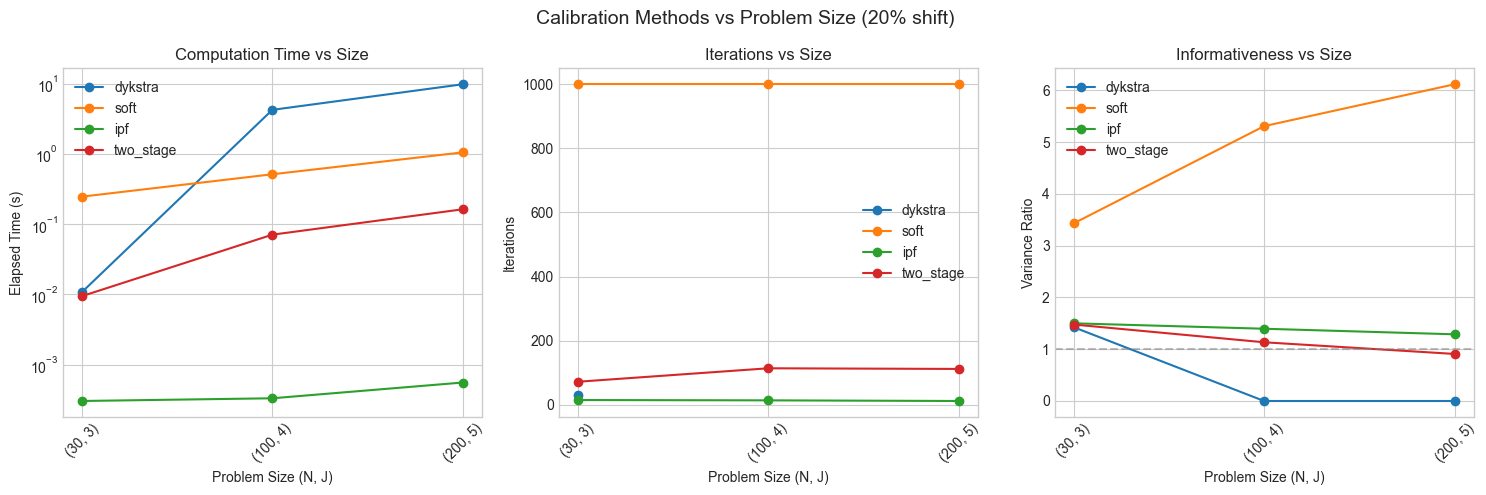

In [8]:
# Visualize size experiment results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Calibration Methods vs Problem Size (20% shift)", fontsize=14)

methods_to_plot = ["dykstra", "soft", "ipf", "two_stage"]
size_labels = df_size["size_label"].unique()

# 1. Elapsed time vs size
ax = axes[0]
for method in methods_to_plot:
    data = df_size[df_size["name"] == method]
    if len(data) > 0:
        ax.plot(range(len(data)), data["elapsed_time"].values, "o-", label=method)
ax.set_xticks(range(len(size_labels)))
ax.set_xticklabels(size_labels, rotation=45)
ax.set_xlabel("Problem Size (N, J)")
ax.set_ylabel("Elapsed Time (s)")
ax.set_title("Computation Time vs Size")
ax.legend()
ax.set_yscale("log")

# 2. Iterations vs size
ax = axes[1]
for method in methods_to_plot:
    data = df_size[df_size["name"] == method]
    if len(data) > 0:
        iters = data["iterations"].replace(-1, np.nan).values
        ax.plot(range(len(data)), iters, "o-", label=method)
ax.set_xticks(range(len(size_labels)))
ax.set_xticklabels(size_labels, rotation=45)
ax.set_xlabel("Problem Size (N, J)")
ax.set_ylabel("Iterations")
ax.set_title("Iterations vs Size")
ax.legend()

# 3. Variance ratio vs size
ax = axes[2]
for method in methods_to_plot:
    data = df_size[df_size["name"] == method]
    if len(data) > 0:
        ax.plot(
            range(len(data)),
            data["variance_ratio"].fillna(0).values,
            "o-",
            label=method,
        )
ax.axhline(y=1.0, color="gray", linestyle="--", alpha=0.5)
ax.set_xticks(range(len(size_labels)))
ax.set_xticklabels(size_labels, rotation=45)
ax.set_xlabel("Problem Size (N, J)")
ax.set_ylabel("Variance Ratio")
ax.set_title("Informativeness vs Size")
ax.legend()

plt.tight_layout()
plt.show()

## 5. Experiment 3: Soft Penalty Pareto Frontier

Grid search over soft calibration penalties to understand the trade-off space.

In [9]:
def run_soft_grid_search(
    lam_m_values: list[float] = [0.1, 1.0, 10.0],
    lam_r_values: list[float] = [0.1, 1.0, 10.0],
    N: int = 50,
    J: int = 3,
    shift_pct: float = 30.0,
    seed: int = 42,
) -> pd.DataFrame:
    """Grid search over soft calibration parameters."""

    P, M, info = generate_shifted_data(N=N, J=J, shift_pct=shift_pct, seed=seed)

    results = []

    for lam_m in lam_m_values:
        for lam_r in lam_r_values:
            result = run_method("soft", P, M, lam_m=lam_m, lam_r=lam_r)
            metrics = collect_metrics(P, M, result)
            results.append(metrics)

    # Also add baseline methods for comparison
    for method_name in ["dykstra", "two_stage"]:
        result = run_method(method_name, P, M)
        metrics = collect_metrics(P, M, result)
        results.append(metrics)

    return pd.DataFrame(results)


# Run grid search
print("Experiment 3: Soft Penalty Grid Search")
print("=" * 40)
df_grid = run_soft_grid_search(shift_pct=30.0)
print(f"\nCollected {len(df_grid)} results")

Experiment 3: Soft Penalty Grid Search



Collected 11 results


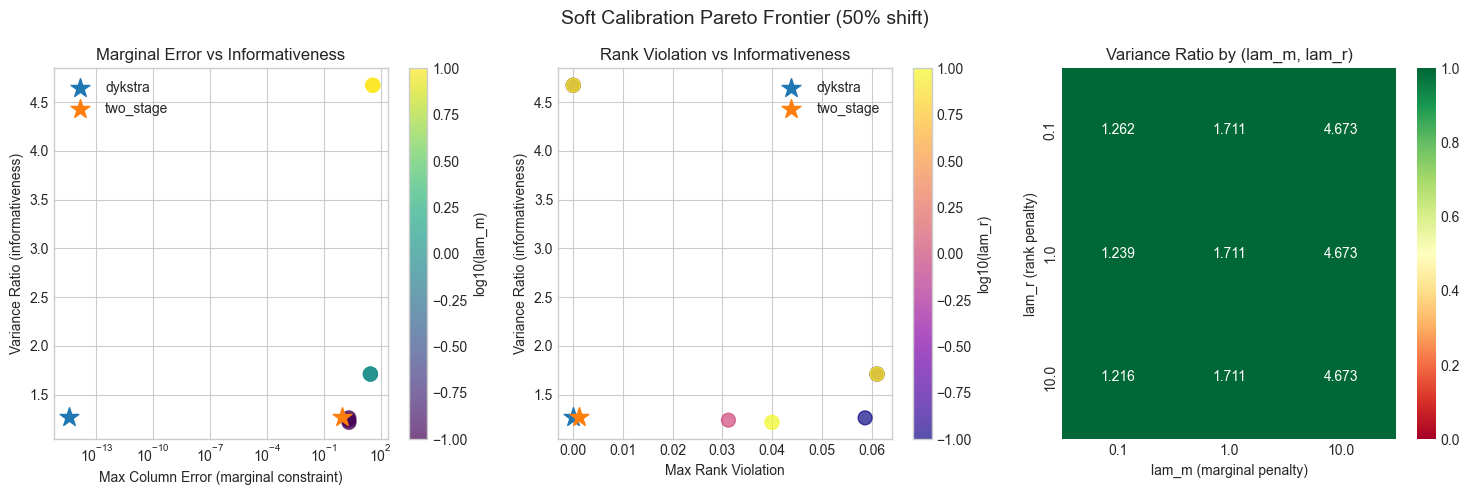

In [10]:
# Visualize Pareto frontier
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Soft Calibration Pareto Frontier (50% shift)", fontsize=14)

# Filter soft results
df_soft = df_grid[df_grid["name"].str.startswith("soft")].copy()
df_baseline = df_grid[~df_grid["name"].str.startswith("soft")]

# 1. Marginal error vs Variance ratio
ax = axes[0]
scatter = ax.scatter(
    df_soft["max_col_error"],
    df_soft["variance_ratio"],
    c=np.log10(df_soft["lam_m"]),
    cmap="viridis",
    s=100,
    alpha=0.7,
)
plt.colorbar(scatter, ax=ax, label="log10(lam_m)")

# Add baselines
for _, row in df_baseline.iterrows():
    ax.scatter(
        row["max_col_error"],
        row["variance_ratio"],
        marker="*",
        s=200,
        label=row["name"],
    )

ax.set_xlabel("Max Column Error (marginal constraint)")
ax.set_ylabel("Variance Ratio (informativeness)")
ax.set_title("Marginal Error vs Informativeness")
ax.legend()
ax.set_xscale("log")

# 2. Rank violation vs Variance ratio
ax = axes[1]
scatter = ax.scatter(
    df_soft["max_rank_violation"],
    df_soft["variance_ratio"],
    c=np.log10(df_soft["lam_r"]),
    cmap="plasma",
    s=100,
    alpha=0.7,
)
plt.colorbar(scatter, ax=ax, label="log10(lam_r)")

for _, row in df_baseline.iterrows():
    ax.scatter(
        row["max_rank_violation"],
        row["variance_ratio"],
        marker="*",
        s=200,
        label=row["name"],
    )

ax.set_xlabel("Max Rank Violation")
ax.set_ylabel("Variance Ratio (informativeness)")
ax.set_title("Rank Violation vs Informativeness")
ax.legend()

# 3. Heatmap of variance ratio by (lam_m, lam_r)
ax = axes[2]

# Pivot for heatmap
pivot_data = df_soft.pivot_table(
    index="lam_r", columns="lam_m", values="variance_ratio", aggfunc="mean"
)

sns.heatmap(
    pivot_data,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn",
    ax=ax,
    vmin=0,
    vmax=1,
)
ax.set_title("Variance Ratio by (lam_m, lam_r)")
ax.set_xlabel("lam_m (marginal penalty)")
ax.set_ylabel("lam_r (rank penalty)")

plt.tight_layout()
plt.show()

In [11]:
# Show grid search results table
print("\nSoft Calibration Grid Search Results")
print("=" * 80)

df_soft_display = df_soft[
    [
        "lam_m",
        "lam_r",
        "variance_ratio",
        "max_col_error",
        "max_rank_violation",
        "converged",
    ]
].sort_values(["lam_m", "lam_r"])

print(df_soft_display.to_string(index=False))

# Find best trade-off
print("\nBest by variance ratio (informativeness):")
best_var = df_soft.loc[df_soft["variance_ratio"].idxmax()]
print(
    f"  lam_m={best_var['lam_m']}, lam_r={best_var['lam_r']}: variance_ratio={best_var['variance_ratio']:.4f}"
)

print("\nBest by marginal constraint:")
best_marg = df_soft.loc[df_soft["max_col_error"].idxmin()]
print(
    f"  lam_m={best_marg['lam_m']}, lam_r={best_marg['lam_r']}: max_col_error={best_marg['max_col_error']:.6f}"
)


Soft Calibration Grid Search Results
 lam_m  lam_r  variance_ratio  max_col_error  max_rank_violation  converged
   0.1    0.1        1.262225       2.087220            0.058713      False
   0.1    1.0        1.238797       2.103267            0.031219      False
   0.1   10.0        1.216250       2.136327            0.039983      False
   1.0    0.1        1.711420      28.830727            0.061108      False
   1.0    1.0        1.711420      28.830727            0.061108      False
   1.0   10.0        1.711420      28.830727            0.061108      False
  10.0    0.1        4.672991      38.417798            0.000000      False
  10.0    1.0        4.672991      38.417798            0.000000      False
  10.0   10.0        4.672991      38.417798            0.000000      False

Best by variance ratio (informativeness):
  lam_m=10.0, lam_r=0.1: variance_ratio=4.6730

Best by marginal constraint:
  lam_m=0.1, lam_r=0.1: max_col_error=2.087220


## 6. Experiment 4: Realistic Scenarios

Test methods on realistic use cases: classifier calibration and survey reweighting.

In [12]:
def run_realistic_scenarios(seed: int = 42) -> dict:
    """Run all methods on realistic scenarios."""

    scenarios = {}

    # Scenario 1: Overconfident classifier
    print("Running: Overconfident Classifier")
    P1, M1, info1 = create_realistic_classifier_case(
        N=200, J=4, miscalibration_type="overconfident", seed=seed
    )
    scenarios["overconfident"] = {"P": P1, "M": M1, "info": info1}

    # Scenario 2: Survey reweighting
    print("Running: Survey Reweighting")
    P2, M2, info2 = create_survey_reweighting_case(N=300, seed=seed)
    scenarios["survey"] = {"P": P2, "M": M2, "info": info2}

    return scenarios


def evaluate_scenario(name: str, P: np.ndarray, M: np.ndarray) -> pd.DataFrame:
    """Evaluate all methods on a scenario."""

    methods = [
        ("dykstra", {}),
        ("soft", {"lam_m": 1.0, "lam_r": 10.0}),
        ("soft", {"lam_m": 10.0, "lam_r": 1.0}),
        ("ipf", {}),
        ("two_stage", {}),
    ]

    results = []

    for method_name, kwargs in methods:
        result = run_method(method_name, P, M, **kwargs)
        metrics = collect_metrics(P, M, result)
        metrics["scenario"] = name

        if method_name == "soft":
            lam_m = kwargs.get("lam_m", 1.0)
            lam_r = kwargs.get("lam_r", 10.0)
            metrics["name"] = f"soft(m={lam_m},r={lam_r})"

        results.append(metrics)

    return pd.DataFrame(results)


# Run realistic scenarios
print("Experiment 4: Realistic Scenarios")
print("=" * 40)
scenarios = run_realistic_scenarios()

df_scenarios = pd.concat(
    [evaluate_scenario(name, data["P"], data["M"]) for name, data in scenarios.items()]
)

print(f"\nCollected {len(df_scenarios)} results")

Experiment 4: Realistic Scenarios
Running: Overconfident Classifier
Running: Survey Reweighting



Collected 10 results


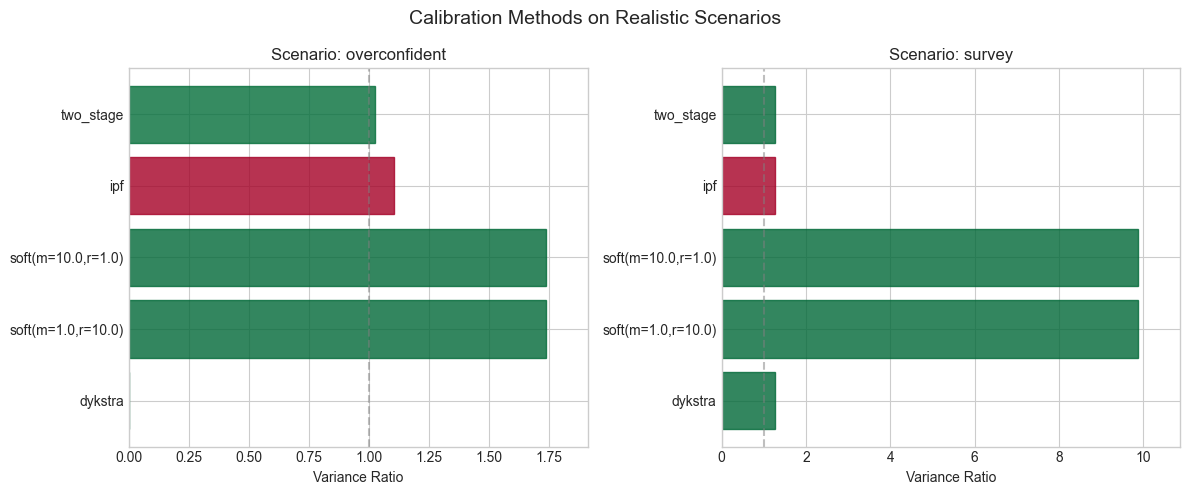

In [13]:
# Visualize realistic scenario results
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Calibration Methods on Realistic Scenarios", fontsize=14)

scenario_names = ["overconfident", "survey"]

for idx, scenario in enumerate(scenario_names):
    ax = axes[idx]
    df_scen = df_scenarios[df_scenarios["scenario"] == scenario]

    # Bar chart of variance ratio
    methods = df_scen["name"].values
    var_ratios = df_scen["variance_ratio"].fillna(0).values

    bars = ax.barh(methods, var_ratios, alpha=0.8)
    ax.axvline(x=1.0, color="gray", linestyle="--", alpha=0.5)
    ax.set_xlabel("Variance Ratio")
    ax.set_title(f"Scenario: {scenario}")
    ax.set_xlim(0, max(1.5, var_ratios.max() * 1.1))

    # Color by rank violation
    rank_viols = df_scen["max_rank_violation"].fillna(0).values
    max_viol = max(rank_viols) + 1e-10
    colors = plt.cm.RdYlGn(1 - rank_viols / max_viol)
    for bar, color in zip(bars, colors):
        bar.set_color(color)

plt.tight_layout()
plt.show()

In [14]:
# Summary table for realistic scenarios
print("\nRealistic Scenarios Summary")
print("=" * 100)

for scenario in ["overconfident", "survey"]:
    print(f"\n{scenario.upper()}:")
    df_scen = df_scenarios[df_scenarios["scenario"] == scenario][
        [
            "name",
            "variance_ratio",
            "max_col_error",
            "max_rank_violation",
            "pred_change_rate",
            "converged",
            "failed",
        ]
    ].copy()
    df_scen = df_scen.sort_values("variance_ratio", ascending=False)
    print(df_scen.to_string(index=False))


Realistic Scenarios Summary

OVERCONFIDENT:
              name  variance_ratio  max_col_error  max_rank_violation  pred_change_rate  converged  failed
soft(m=1.0,r=10.0)        1.737727   1.370000e+02            0.000000             0.690      False   False
soft(m=10.0,r=1.0)        1.737727   1.370000e+02            0.000000             0.690      False   False
               ipf        1.103477   9.701918e-07            0.247521             0.015       True   False
         two_stage        1.024997   5.764542e+00            0.003518             0.015       True   False
           dykstra             NaN            NaN                 NaN               NaN      False    True

SURVEY:
              name  variance_ratio  max_col_error  max_rank_violation  pred_change_rate  converged  failed
soft(m=1.0,r=10.0)        9.882335   1.933500e+02        0.000000e+00          0.443333      False   False
soft(m=10.0,r=1.0)        9.882335   1.933500e+02        0.000000e+00          0.443333   

## 7. Summary and Recommendations

Based on the experiments, here are recommendations for method selection.

In [15]:
print("=" * 80)
print("SUMMARY: CALIBRATION METHOD RECOMMENDATIONS")
print("=" * 80)

print("""
1. SMALL SHIFT (< 10%)
   Best: calibrate_dykstra or calibrate_admm
   - Both achieve exact constraint satisfaction
   - Minimal flatness (high variance ratio)
   - Fast convergence

2. MODERATE SHIFT (10-50%)
   Best: calibrate_two_stage or calibrate_soft with tuned penalties
   - two_stage: Good balance of marginals and informativeness
   - soft(lam_m=1, lam_r=10): Prioritizes rank preservation
   - Dykstra/ADMM may produce flat solutions

3. LARGE SHIFT (> 50%)
   Best: calibrate_soft with low lam_m or calibrate_ipf
   - Exact methods will be very flat
   - Accept trade-off: less exact marginals, more informative
   - IPF preserves ratios but has rank violations
   
4. SURVEY REWEIGHTING
   Best: calibrate_ipf or calibrate_two_stage
   - IPF is the classical raking method
   - two_stage adds rank constraint if needed

5. CLASSIFIER CALIBRATION
   Best: Depends on shift magnitude
   - Small shift: Dykstra for exact calibration
   - Large shift: soft with tuned penalties
   - Overconfident: Consider soft(lam_m=10, lam_r=1)

KEY TRADE-OFFS:
- variance_ratio > 0.8: Good informativeness
- variance_ratio < 0.3: Solution is too flat
- max_col_error < 1e-6: Exact marginal satisfaction
- max_rank_violation < 1e-6: Exact rank preservation
""")

# Create final comparison table
print("\nMETHOD CHARACTERISTICS:")
print("-" * 80)

method_chars = pd.DataFrame(
    {
        "Method": ["dykstra", "admm", "soft", "soft_admm", "ipf", "two_stage"],
        "Exact Marginals": [
            "Yes",
            "Yes",
            "No (tunable)",
            "No (tunable)",
            "Approx",
            "Approx",
        ],
        "Exact Ranks": ["Yes", "Yes", "No (tunable)", "No (tunable)", "No", "Approx"],
        "Flatness Risk": [
            "High (large shift)",
            "High (large shift)",
            "Low (tunable)",
            "Low (tunable)",
            "Low",
            "Medium",
        ],
        "Best For": [
            "Small shift",
            "Small shift",
            "Large shift",
            "Large shift",
            "Survey",
            "Balanced",
        ],
    }
)

print(method_chars.to_string(index=False))

SUMMARY: CALIBRATION METHOD RECOMMENDATIONS

1. SMALL SHIFT (< 10%)
   Best: calibrate_dykstra or calibrate_admm
   - Both achieve exact constraint satisfaction
   - Minimal flatness (high variance ratio)
   - Fast convergence

2. MODERATE SHIFT (10-50%)
   Best: calibrate_two_stage or calibrate_soft with tuned penalties
   - two_stage: Good balance of marginals and informativeness
   - soft(lam_m=1, lam_r=10): Prioritizes rank preservation
   - Dykstra/ADMM may produce flat solutions

3. LARGE SHIFT (> 50%)
   Best: calibrate_soft with low lam_m or calibrate_ipf
   - Exact methods will be very flat
   - Accept trade-off: less exact marginals, more informative
   - IPF preserves ratios but has rank violations

4. SURVEY REWEIGHTING
   Best: calibrate_ipf or calibrate_two_stage
   - IPF is the classical raking method
   - two_stage adds rank constraint if needed

5. CLASSIFIER CALIBRATION
   Best: Depends on shift magnitude
   - Small shift: Dykstra for exact calibration
   - Large shif

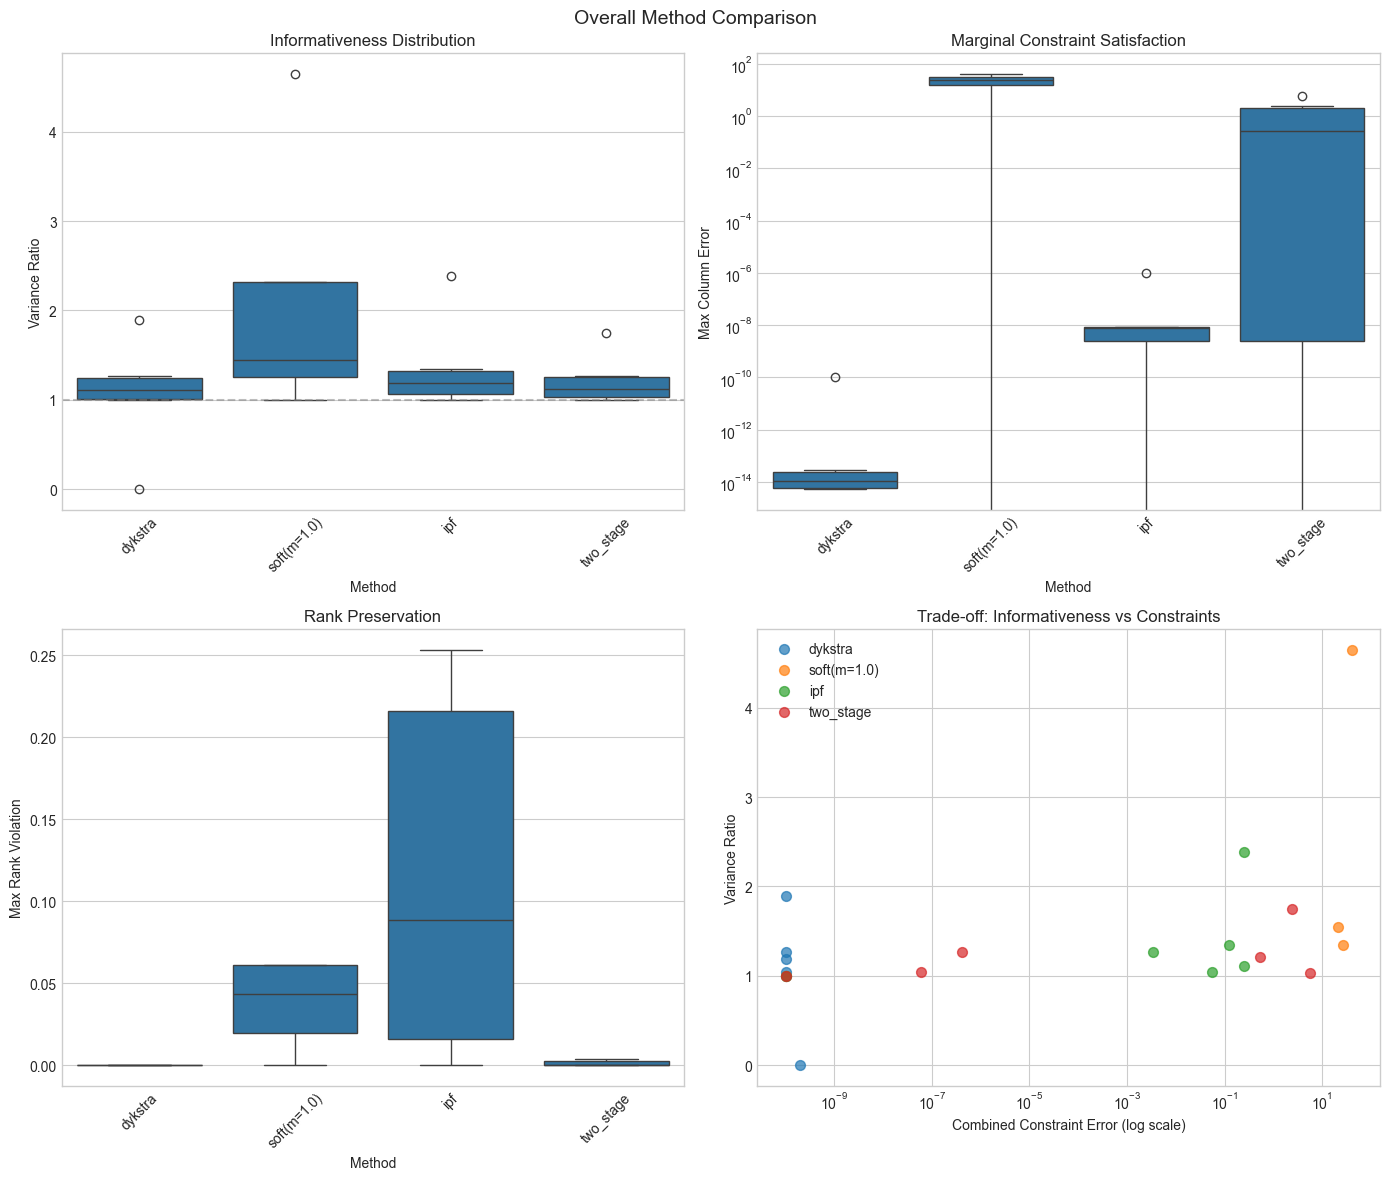

In [16]:
# Final visualization: method comparison across all experiments
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle("Overall Method Comparison", fontsize=14)

# Aggregate results
all_results = pd.concat([df_shift, df_scenarios]).reset_index(drop=True)

# 1. Box plot of variance ratio by method
ax = axes[0, 0]
methods_order = ["dykstra", "soft(m=1.0)", "ipf", "two_stage"]
data_to_plot = all_results[all_results["name"].isin(methods_order)].copy()
data_to_plot["variance_ratio"] = data_to_plot["variance_ratio"].fillna(0)

if len(data_to_plot) > 0:
    sns.boxplot(
        data=data_to_plot, x="name", y="variance_ratio", ax=ax, order=methods_order
    )
    ax.axhline(y=1.0, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Method")
ax.set_ylabel("Variance Ratio")
ax.set_title("Informativeness Distribution")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

# 2. Box plot of max_col_error by method
ax = axes[0, 1]
data_to_plot["max_col_error_safe"] = data_to_plot["max_col_error"].fillna(1e-10)
if len(data_to_plot) > 0:
    sns.boxplot(
        data=data_to_plot, x="name", y="max_col_error_safe", ax=ax, order=methods_order
    )
ax.set_xlabel("Method")
ax.set_ylabel("Max Column Error")
ax.set_title("Marginal Constraint Satisfaction")
ax.set_yscale("log")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

# 3. Box plot of max_rank_violation by method
ax = axes[1, 0]
data_to_plot["max_rank_violation_safe"] = data_to_plot["max_rank_violation"].fillna(0)
if len(data_to_plot) > 0:
    sns.boxplot(
        data=data_to_plot,
        x="name",
        y="max_rank_violation_safe",
        ax=ax,
        order=methods_order,
    )
ax.set_xlabel("Method")
ax.set_ylabel("Max Rank Violation")
ax.set_title("Rank Preservation")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

# 4. Scatter: variance ratio vs constraint satisfaction
ax = axes[1, 1]
for method in methods_order:
    method_data = data_to_plot[data_to_plot["name"] == method]
    if len(method_data) > 0:
        combined_error = (
            method_data["max_col_error_safe"]
            + method_data["max_rank_violation_safe"]
            + 1e-10
        )
        ax.scatter(
            combined_error, method_data["variance_ratio"], label=method, alpha=0.7, s=50
        )
ax.set_xlabel("Combined Constraint Error (log scale)")
ax.set_ylabel("Variance Ratio")
ax.set_title("Trade-off: Informativeness vs Constraints")
ax.set_xscale("log")
ax.legend()

plt.tight_layout()
plt.show()

## 8. Conclusions

This notebook demonstrates that:

1. **No single method is best for all scenarios** - the optimal choice depends on shift magnitude and priorities.

2. **Exact methods (Dykstra/ADMM) excel at small shifts** but produce flat solutions when shifts are large.

3. **Soft calibration provides tunable trade-offs** - use higher `lam_m` for stricter marginals, higher `lam_r` for stricter ranks.

4. **Two-stage IPF offers a good middle ground** - preserves more structure than exact methods while approximately satisfying constraints.

5. **Pure IPF is best for survey reweighting** where rank preservation is less critical.

Use the `flatness_bound` function to assess risk before calibration, and `compare_calibration_methods` to evaluate multiple approaches on your specific data.